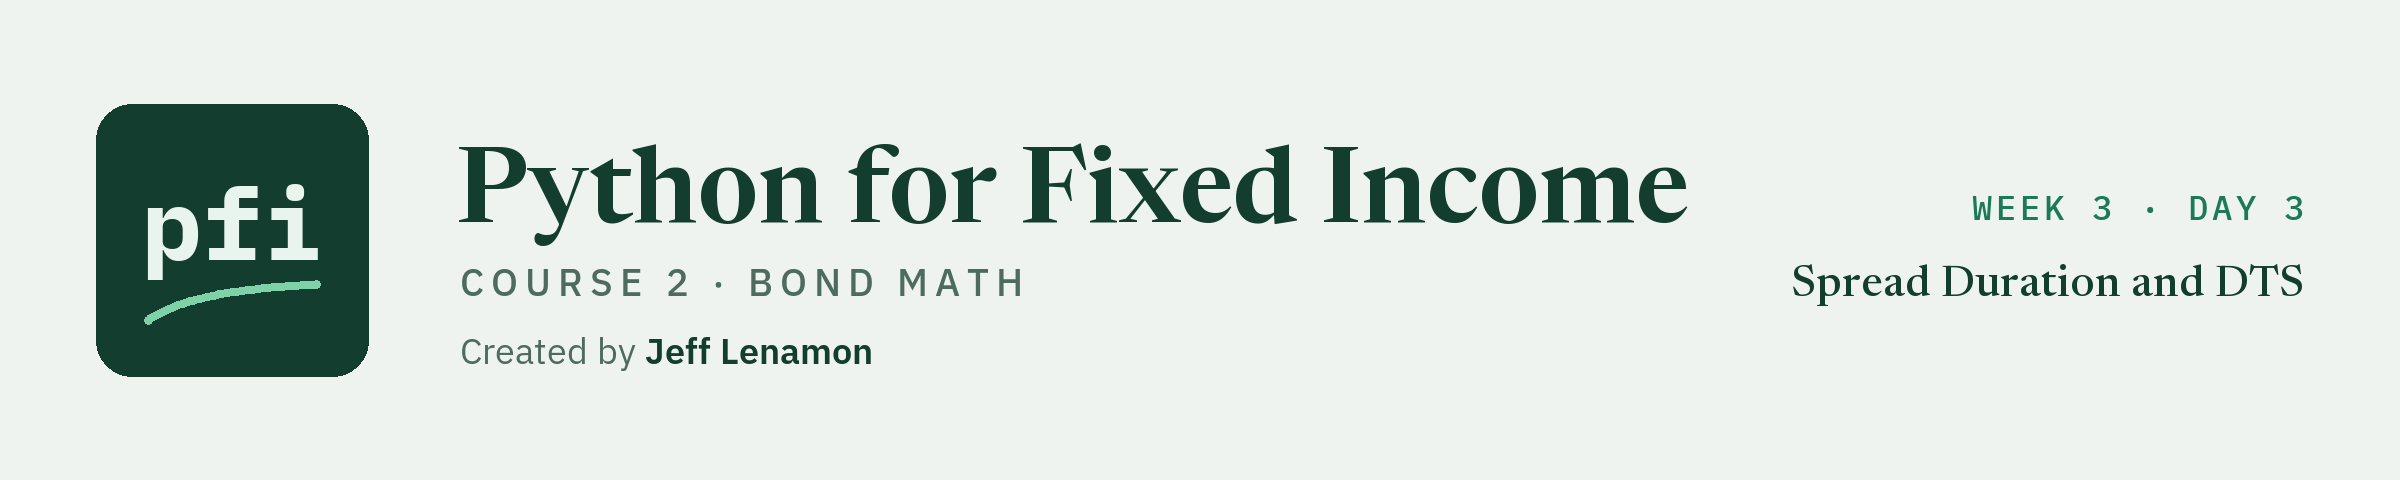

# Spread Duration and DTS

Week 3, Day 3. How far a bond's price moves when its spread moves: spread duration by bumping the spread, why it equals modified duration for these bonds, DTS, the holdings file's two columns reproduced, and where the book's DTS sits.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week3/day3/13_spread_duration_and_dts.ipynb)

Yesterday you computed each bond's spread to the curve and reproduced the `oas` column of `holdings.csv` exactly. A spread is a level. A desk also needs its sensitivity: **if the spread moves, how far does the price move?**

That is today's question, asked of the same 200 bonds as of 30 September 2026. The answer has two parts. **Spread duration** says how much the price moves for a given move in the spread. **DTS**, duration times spread, is a published measure that multiplies spread duration by the spread itself. Both are columns of the holdings file, `spread_duration` and `dts`, and by the end of today you will have rebuilt both from the bond math.

Today you will:

1. Measure spread duration by moving the spread down and up 1 basis point and repricing.
2. See why, for a bond priced at the curve plus a spread, spread duration equals modified duration, and why the bump sits a hair above it.
3. Compute DTS, and see what the product measures.
4. Reproduce the file's `spread_duration` and `dts` columns for all 200 bonds.
5. Add up DTS by rating bucket, and find each bond's contribution to the book's DTS, as the Course 1 project did, now from first principles.

The issuers are invented, and so is every number. Every table today describes the synthetic book. Nothing below says a bond, an issuer, or a rating bucket is good value or poor value, and nothing says how much DTS a book should carry.

The setup cell is the same as every day. Then the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 12.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_13_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_13_4zmrbhif, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]


BASIS = {"0": "30/360", "1": "ACT/ACT"}  # Excel's basis number to bondmath's name


def bond_inputs(row: dict) -> tuple:
    """settlement, maturity, coupon_pct, yield_pct, frequency, basis from a reference row, in bondmath's units."""
    return (date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"]),
            float(row["coupon_pct"]), float(row["yield_pct"]), int(row["frequency"]), BASIS[row["basis"]])


def test_days_30_360_rule_cases():
    # (start, end, expected days, the Excel function that confirms the value)
    cases = [
        (date(2026, 8, 16), date(2026, 9, 30), 44, "COUPDAYBS"),    # no rule applies
        (date(2027, 2, 28), date(2027, 3, 1), 1, "COUPDAYBS"),      # rule 1: last day of February counts as 30
        (date(2027, 2, 28), date(2028, 2, 29), 360, "YEARFRAC"),    # rule 2: both on the last day of February
        (date(2026, 8, 31), date(2026, 9, 30), 30, "COUPDAYBS"),    # rule 3: a 31st start counts as 30
        (date(2026, 7, 30), date(2026, 10, 31), 90, "COUPDAYBS"),   # rule 4: a 31st end after a 30th start
        (date(2026, 10, 15), date(2026, 10, 31), 16, "COUPDAYBS"),  # a 31st end after a 15th start stays 31
        (date(2027, 2, 28), date(2027, 3, 31), 31, "COUPDAYBS"),    # rule 1, and the 31st end stays 31
        (date(2026, 11, 15), date(2027, 2, 28), 103, "COUPDAYBS"),  # an end on 28 February is not changed
    ]
    for start, end, expected, source in cases:
        assert bondmath.days_30_360(start, end) == expected, (start, end)
        if source == "COUPDAYBS":
            # the same pair of dates appears in the reference file as previous coupon and settlement
            matches = [row for row in REFERENCE if row["basis"] == "0" and row["couppcd"] == start.isoformat()
                       and row["settlement"] == end.isoformat()]
            assert matches, f"no reference row with previous coupon {start} and settlement {end}"
            assert int(matches[0]["coupdaybs"]) == expected
        # the YEARFRAC value, YEARFRAC(start, end, 0) x 360 = 360, was checked in Excel by the reference tool


def test_coupon_period_days_match_excel():
    for row in REFERENCE:
        settlement, maturity, _, _, frequency, basis = bond_inputs(row)
        days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
        # A is COUPDAYBS under both bases
        assert days_accrued == int(row["coupdaybs"]), row["case_id"]
        if basis == "30/360":
            # E is COUPDAYS, and PRICE uses DSC = E - A
            assert days_in_period == int(row["coupdays"]), row["case_id"]
            assert days_to_next == int(row["coupdays"]) - int(row["coupdaybs"]), row["case_id"]
        else:
            # E is the actual length of the period, which PRICE uses (Excel's COUPDAYS with basis 1 can differ)
            period_start, period_end = date.fromisoformat(row["couppcd"]), date.fromisoformat(row["coupncd"])
            assert days_in_period == (period_end - period_start).days, row["case_id"]
            assert days_to_next == int(row["coupdaysnc"]), row["case_id"]


def test_accrued_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        result = bondmath.accrued_interest(settlement, maturity, coupon_pct, frequency, basis)
        assert result == pytest.approx(float(row["accrued"]), abs=1e-9), row["case_id"]


def test_price_matches_excel():
    for row in REFERENCE:
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_dirty_is_clean_plus_accrued():
    for row in REFERENCE:
        result = bondmath.dirty_price(*bond_inputs(row))
        # Excel's PRICE plus Excel's accrued formula
        assert result == pytest.approx(float(row["price"]) + float(row["accrued"]), abs=1e-6), row["case_id"]


def test_price_on_coupon_date_equals_week1():
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # on a coupon date the bond has a whole number of periods left
        years = int(row["coupnum"]) / frequency
        week1_price = bondmath.price_from_yield(coupon_pct, yield_pct, years, frequency)
        assert bondmath.price(settlement, maturity, coupon_pct, yield_pct, frequency, basis) == pytest.approx(
            week1_price, abs=1e-9), row["case_id"]


def test_final_period_matches_excel():
    final_period_rows = [row for row in REFERENCE if row["coupnum"] == "1"]
    assert final_period_rows, "no final-period rows in the reference file"
    for row in final_period_rows:
        # one coupon left: Excel prices it with simple interest
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_yield_to_maturity_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        # solve the yield from Excel's price, and compare with Excel's YIELD of that price
        result = bondmath.yield_to_maturity(settlement, maturity, coupon_pct, float(row["price"]), frequency, basis)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_macaulay_matches_excel_duration():
    for row in REFERENCE:
        result = bondmath.macaulay_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["duration"]), abs=1e-6), row["case_id"]


def test_modified_matches_excel_mduration():
    for row in REFERENCE:
        result = bondmath.modified_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["mduration"]), abs=1e-6), row["case_id"]


def test_dv01_matches_excel_formula():
    for row in REFERENCE:
        result = bondmath.dv01(*bond_inputs(row))
        # Excel: MDURATION x (PRICE + accrued) / 10000
        assert result == pytest.approx(float(row["dv01"]), abs=1e-8), row["case_id"]


def test_dv01_close_to_bump():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # Excel's PRICE 1 bp lower and 1 bp higher, half the difference
        bump = (float(row["price_down_1bp"]) - float(row["price_up_1bp"])) / 2
        assert bondmath.dv01(*bond_inputs(row)) == pytest.approx(bump, abs=1e-6), row["case_id"]


def test_convexity_matches_excel_finite_difference():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: Excel prices it with simple interest, so its curvature is not comparable
        # Excel: (PRICE(y+h) + PRICE(y-h) - 2 PRICE(y)) / ((PRICE(y) + accrued) h^2), with h = 1 bp
        result = bondmath.convexity(*bond_inputs(row))
        assert result == pytest.approx(float(row["convexity_fd"]), abs=1e-3), row["case_id"]


# The invented curve the holdings file was built on, at ten tenors: round(3.55 + 1.05 x (1 - exp(-T / 7)), 3)
CURVE_TENORS = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
CURVE_YIELDS_PCT = [3.587, 3.622, 3.69, 3.811, 3.916, 4.086, 4.214, 4.348, 4.54, 4.586]


def test_on_a_tenor_returns_its_yield():
    for tenor, yield_pct in zip(CURVE_TENORS, CURVE_YIELDS_PCT):
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(yield_pct, abs=1e-12)


def test_matches_numpy_interp():
    import numpy as np  # numpy is in the course requirements; bondmath itself does not use it

    for tenor in (0.1, 0.92, 1.5, 4.0, 6.4, 8.75, 15.0, 29.9, 35.0):
        expected = float(np.interp(tenor, CURVE_TENORS, CURVE_YIELDS_PCT))
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(expected, abs=1e-12)


def test_flat_beyond_the_ends():
    # below the first tenor: the first yield; above the last: the last yield
    assert bondmath.interpolate_yield(0.1, CURVE_TENORS, CURVE_YIELDS_PCT) == 3.587
    assert bondmath.interpolate_yield(40, CURVE_TENORS, CURVE_YIELDS_PCT) == 4.586


def test_raises_when_tenors_not_ascending():
    with pytest.raises(ValueError):
        bondmath.interpolate_yield(4, [1, 3, 2], [3.7, 3.9, 3.8])


def test_years_to_maturity_cases():
    # (settlement, maturity, 30/360 days); each was checked in Excel as YEARFRAC(settlement, maturity, 0) x 360
    cases = [
        (date(2026, 9, 30), date(2036, 9, 30), 3600),  # exactly ten years
        (date(2026, 9, 30), date(2032, 6, 18), 2058),  # the first bond in holdings.csv
        (date(2027, 2, 28), date(2031, 8, 31), 1621),  # the 31st end stays 31 after a 28 February start
    ]
    for settlement, maturity, days in cases:
        assert bondmath.years_to_maturity(settlement, maturity) == pytest.approx(days / 360, abs=1e-12)


def test_spread_to_curve_known_case():
    # a 5 percent yield at 6 years: halfway between the 5-year (4.086) and 7-year (4.214) points
    curve_at_6_years = 4.086 + (4.214 - 4.086) * (6 - 5) / (7 - 5)
    expected_bp = (5.0 - curve_at_6_years) * 100
    result = bondmath.spread_to_curve_bp(5.0, 6.0, CURVE_TENORS, CURVE_YIELDS_PCT)
    assert result == pytest.approx(expected_bp, abs=1e-9)


def test_spread_reproduces_oas_rows():
    # five rows of holdings.csv (as of 2026-09-30): cusip, maturity, yield_pct, oas
    rows = [
        ("99080CAE8", date(2032, 6, 18), 5.606, 147),
        ("99049XAE2", date(2029, 4, 17), 9.22, 535),
        ("99039NAC0", date(2030, 6, 3), 5.509, 153),
        ("99039NAG1", date(2053, 4, 9), 6.756, 218),
        ("99034IAD4", date(2036, 4, 5), 5.6, 127),
    ]
    for cusip, maturity, yield_pct, oas in rows:
        years = bondmath.years_to_maturity(date(2026, 9, 30), maturity)
        # the file was built on the curve's formula at the bond's own maturity, rounded to 3 decimals,
        # so a one-point curve at exactly that maturity gives the file's spread
        curve_yield_pct = round(3.55 + 1.05 * (1 - math.exp(-years / 7)), 3)
        result = bondmath.spread_to_curve_bp(yield_pct, years, [years], [curve_yield_pct])
        assert result == pytest.approx(oas, abs=1e-9), cusip

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price', 'add_months', 'coupon_dates', 'days_30_360', 'coupon_period_days', 'accrued_interest', 'price', 'dirty_price', 'yield_to_maturity', 'macaulay_duration', 'modified_duration', 'dv01', 'convexity', 'interpolate_yield', 'years_to_maturity', 'spread_to_curve_bp']


* The two files exactly as day 12 left them: 21 functions and 35 tests. By the end of today there will be 23 functions and 37 tests.

Today's Git step searches the history for the commit where a number first appeared, so the work folder needs a history with one commit for each day. Your own `my_bondmath` folder has that history already, one commit a day or more since day 1. This work folder is new today, so the next cells rebuild it from the start-of-day files.

Q. Make the work folder a repository.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_13_4zmrbhif and nowhere else


* Git is working in the work folder, and nowhere else.

Each day's code was added at the end of the two files, so every earlier day's file is the front part of today's: the file at the end of day 8 is everything above day 9's first line. The next cell holds the first line each day added to each file, cuts the files back day by day, and commits each day's version.

Q. Rebuild the history: one commit for each of days 1 to 12.

In [7]:
def front_part(text, first_line_of_later_code):
    """The part of a file above a later day's first line: the file as it stood before that day."""
    cut = text.index("\n" + first_line_of_later_code)
    return text[:cut].rstrip("\n") + "\n"


def through_day(text, starts, day):
    """The file at the end of `day`: everything above the first line of the next day that added to it."""
    later = [line for d, line in starts.items() if d > day]
    return front_part(text, later[0]) if later else text


# the first line each day added to each file (day 5 added tests only)
module_starts = {
    2: 'def cash_flows(',
    3: 'def convert_yield(',
    4: 'def yield_from_price(',
    6: 'def add_months(',
    7: 'def days_30_360(',
    8: 'def price(',
    9: 'def macaulay_duration(',
    10: 'def convexity(',
    11: 'def interpolate_yield(',
    12: 'def years_to_maturity(',
}
test_starts = {
    2: 'REFERENCE = read_rows(',
    3: 'def test_convert_yield_matches_excel_effect_and_nominal(',
    4: 'def test_yield_from_price_matches_excel(',
    5: 'def test_par_bond_prices_at_100(',
    6: 'def test_add_months_clamps_to_month_end(',
    7: 'BASIS = {"0": "30/360", "1": "ACT/ACT"}  # Excel\'s basis number to bondmath\'s name',
    8: 'def test_price_matches_excel(',
    9: 'def test_macaulay_matches_excel_duration(',
    10: 'def test_convexity_matches_excel_finite_difference(',
    11: '# The invented curve the holdings file was built on, at ten tenors: round(',
    12: 'def test_years_to_maturity_cases(',
}
titles = {
    1: 'Time Value of Money',
    2: 'Cash Flows and Price from Yield',
    3: 'The Price-Yield Relationship',
    4: 'Yield from Price',
    5: 'Case Study: A New Issue Calendar',
    6: 'Dates and Coupon Schedules',
    7: 'Day Counts and Accrued Interest',
    8: 'Clean and Dirty Price',
    9: 'Duration and DV01',
    10: 'Case Study: Convexity and the September Book',
    11: 'Treasury Curve Interpolation',
    12: 'Spread over the Curve',
}

# today's start-of-day files hold every day so far
module_now = Path("bondmath.py").read_text(encoding="utf-8")
tests_now = Path("test_bondmath.py").read_text(encoding="utf-8")

for day in range(1, 13):
    Path("bondmath.py").write_text(through_day(module_now, module_starts, day), encoding="utf-8")
    Path("test_bondmath.py").write_text(through_day(tests_now, test_starts, day), encoding="utf-8")
    message = f"Day {day}: {titles[day]}"
    !git -C "{work}" add bondmath.py test_bondmath.py
    !git -C "{work}" commit -q -m "{message}"

# the last commit, day 12, is exactly the text the setup cell wrote
assert Path("bondmath.py").read_text(encoding="utf-8") == module_now
print(f"bondmath.py: {len(module_now.splitlines())} lines at the start of today")

bondmath.py: 505 lines at the start of today


In [8]:
# the history, newest first
!git -C "{work}" log --oneline

754578d Day 12: Spread over the Curve
8ffc22c Day 11: Treasury Curve Interpolation
093d974 Day 10: Case Study: Convexity and the September Book
f2bfe18 Day 9: Duration and DV01
ec286e3 Day 8: Clean and Dirty Price
95196dd Day 7: Day Counts and Accrued Interest
74c8fc0 Day 6: Dates and Coupon Schedules
6517640 Day 5: Case Study: A New Issue Calendar
a32a8ff Day 4: Yield from Price
7234a36 Day 3: The Price-Yield Relationship
ce090f1 Day 2: Cash Flows and Price from Yield
457597f Day 1: Time Value of Money


* Twelve commits, newest first, one for each day. The hashes change on every run. Git can now answer questions about when each line arrived, and section "Save the Day with Git" asks one.

Q. Read the holdings file, with its dates as `date` values, and Excel's reference file.

In [9]:
holdings = pd.read_csv(data_folder + "holdings.csv")
# bondmath takes datetime.date values
holdings["as_of_date"] = pd.to_datetime(holdings["as_of_date"]).dt.date
holdings["maturity"] = pd.to_datetime(holdings["maturity"]).dt.date

reference = pd.read_csv("bondmath_excel_reference.csv")
print(f"holdings: {len(holdings)} bonds as of {holdings['as_of_date'].iloc[0]}")
holdings[["cusip", "issuer", "rating", "coupon", "maturity", "yield_pct", "oas", "duration", "spread_duration", "dts"]].head()

holdings: 200 bonds as of 2026-09-30


,cusip,issuer,rating,coupon,maturity,yield_pct,oas,duration,spread_duration,dts
0,99080CAE8,Bezane Finance,BBB-,7.000,2032-06-18,5.606,147,4.627,4.627,680.2
1,99049XAE2,Bezamyth Machinery,B,8.125,2029-04-17,9.220,535,2.165,2.165,1158.3
2,99039NAC0,Bezoquil Freight,BB,5.125,2030-06-03,5.509,153,3.250,3.250,497.2
3,99039NAG1,Bezoquil Freight,BB,6.125,2053-04-09,6.756,218,12.113,12.113,2640.6
4,99034IAD4,Bezorin Finance,BBB-,4.625,2036-04-05,5.600,127,7.338,7.338,931.9


* The last three columns are today's subject. In every row shown, `spread_duration` equals `duration`, and `dts` is close to `spread_duration` times `oas`. By section 13.4 you will know why.

## 13.1 Spread Duration by Bumping the Spread

Spread duration answers: **if the spread moves by a small amount, by what share of its value does the price move?** It is measured the way day 9 checked DV01, by moving the input and repricing. Move the spread down 1 basis point, then up 1 basis point, and reprice the bond each time. The difference between the two prices, over the 2 basis points between them, is the slope of price against spread. Divided by the dirty price, it is a share of the bond's value.

The unit needs care. The bump is 1 basis point. In `yield_pct`, which is in percent, that is 0.01. In the slope, which divides by the move as a decimal, it is 0.0001.

Take the first bond of the file, Bezane Finance `99080CAE8`: a 7 percent coupon maturing 2032-06-18, at a yield of 5.606 percent, 147 bp over the curve.

Q. Reprice Bezane with its spread 1 bp lower and 1 bp higher. How far does the price move?

In [10]:
bezane = holdings.iloc[0]
settlement, maturity = bezane["as_of_date"], bezane["maturity"]
coupon_pct, yield_pct = bezane["coupon"], bezane["yield_pct"]

# 1 bp is 0.01 in percent: the spread down 1 bp moves the yield down 0.01
price_spread_down = bondmath.price(settlement, maturity, coupon_pct, yield_pct - 0.01)
price_spread_up = bondmath.price(settlement, maturity, coupon_pct, yield_pct + 0.01)
dirty = bondmath.dirty_price(settlement, maturity, coupon_pct, yield_pct)

print(f"clean price, spread 1 bp lower:  {price_spread_down:.6f} per 100")
print(f"clean price, spread 1 bp higher: {price_spread_up:.6f} per 100")
print(f"difference over 2 bp:            {price_spread_down - price_spread_up:.6f} per 100")
print(f"dirty price:                     {dirty:.6f} per 100")

clean price, spread 1 bp lower:  106.776909 per 100
clean price, spread 1 bp higher: 106.676310 per 100
difference over 2 bp:            0.100600 per 100
dirty price:                     108.709928 per 100


* 0.100600 points per 100 of face across 2 basis points, about 0.0503 a basis point: the bond's DV01, as day 9 measured it. A wider spread gives a lower price.
* The clean prices can be subtracted directly: accrued interest does not depend on the spread, so the clean difference is the dirty difference.

Q. Turn that into spread duration: the slope over 2 x 0.0001, divided by the dirty price.

In [11]:
# the move as a decimal: 2 basis points is 2 x 0.0001
spread_duration_years = (price_spread_down - price_spread_up) / (2 * 0.0001) / dirty
print(f"Bezane's spread duration: {spread_duration_years:.6f} years")
# read it: a 100 bp move in the spread moves the price by about this percent of the dirty price
print(f"a 100 bp wider spread: price about {spread_duration_years:.2f} percent lower")

Bezane's spread duration: 4.626971 years
a 100 bp wider spread: price about 4.63 percent lower


* **4.626971 years.** Spread duration is measured in years, like modified duration. Read it as a sensitivity: the price moves by about 4.63 percent of the dirty price for 100 bp of spread, or 0.0463 percent for 1 bp.

**Excel side by side: spread duration from three `PRICE` cells.** Tested in Excel, for Bezane. In B1 type `=PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,5.606/100,100,2,0)`, the price at the yield. In B2 the same with the yield 1 bp lower, written as a decimal: `=PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,5.606/100-0.0001,100,2,0)`. In B3 one bp higher: `=PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,5.606/100+0.0001,100,2,0)`. In B4 the accrued formula from day 7: `=100*7/100/2*COUPDAYBS(DATE(2026,9,30),DATE(2032,6,18),2,0)/COUPDAYS(DATE(2026,9,30),DATE(2032,6,18),2,0)`. Then in B5: `=(B2-B3)/(2*0.0001)/(B1+B4)`. Excel returns 106.72659513009698 in B1, 106.77690922344026 in B2, 106.67630969052466 in B3, 1.9833333333333334 in B4, and **4.626970799149981** in B5. Notice the units: inside `PRICE` the yield is a decimal, so 1 bp is `0.0001` there and in the slope alike.

Q. Add `spread_duration` to the end of `bondmath.py`. Read it before you run the cell.

In [12]:
%%writefile -a bondmath.py


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price

Appending to bondmath.py


* The docstring states the units (percent in, years out), the convention (the yield is curve plus spread, so a spread move is a yield move), the central difference, and the Excel formula in one cell.
* `bump_pct` moves `yield_pct`, which is in percent. `bump_decimal` divides the slope, which needs a decimal. Two names for one bump, so the two units cannot be mixed up. `bump_bp` defaults to 1 and must be positive: a zero bump would divide by zero.

Q. Reload the module, and check `bondmath.spread_duration` for Bezane against Excel's B5.

In [13]:
importlib.reload(bondmath)

result = bondmath.spread_duration(settlement, maturity, coupon_pct, yield_pct)
excel_b5 = 4.626970799149981  # Excel's B5, tested
print(f"bondmath.spread_duration: {result:.12f} years")
print(f"Excel B5:                 {excel_b5:.12f} years")
print(f"gap: {abs(result - excel_b5):.1e}")

bondmath.spread_duration: 4.626970799151 years
Excel B5:                 4.626970799150 years
gap: 1.3e-12


* The same number to the last digits shown: the function does exactly what the three Excel cells do.

Q. Every holdings bond against Excel. The reference file holds both bumped prices for each of the 200 bonds (`price_down_1bp`, `price_up_1bp`), so Excel's spread duration is one line of pandas.

In [14]:
# the 200 holdings rows of the reference file, one per CUSIP
excel_rows = reference[reference["group"] == "holdings"].set_index("case_id")
excel_rows["excel_spread_duration"] = ((excel_rows["price_down_1bp"] - excel_rows["price_up_1bp"]) / (2 * 0.0001)
                                       / (excel_rows["price"] + excel_rows["accrued"]))

holdings["spread_duration_bm"] = [bondmath.spread_duration(s, m, c, y) for s, m, c, y in
                                  zip(holdings["as_of_date"], holdings["maturity"], holdings["coupon"], holdings["yield_pct"])]
gap = (holdings["spread_duration_bm"] - holdings["cusip"].map(excel_rows["excel_spread_duration"])).abs()
assert (gap < 1e-6).all(), "a bond differs from Excel"
print(f"largest gap to Excel over {len(holdings)} bonds: {gap.max():.1e} years")

largest gap to Excel over 200 bonds: 3.0e-11 years


* All 200 agree with Excel's bumped `PRICE` formula, the largest gap 3.0e-11 years. The new column `spread_duration_bm` holds `bondmath`'s value for every bond.

## 13.2 Why It Equals Modified Duration Here

Day 12 showed how the holdings file was built: each bond's yield is the curve's yield at the bond's maturity, rounded to 3 decimals, plus its spread. So for these bonds,

**yield = curve yield + spread / 100** (yield and curve in percent, spread in basis points).

Hold the curve still and move the spread by 1 bp, and the yield moves by exactly 1 bp. A spread move *is* a yield move. So the slope of price against spread is the slope of price against yield, and that is modified duration, from day 9.

Q. Rebuild Bezane's yield from the curve and its spread, then move the spread rather than the yield.

In [15]:
import math

years = bondmath.years_to_maturity(settlement, maturity)
# the curve's formula from DATA.md, rounded to 3 decimals as the file was built (day 12)
curve_pct = round(3.55 + 1.05 * (1 - math.exp(-years / 7)), 3)
spread_bp = bezane["oas"]
print(f"curve {curve_pct} + spread {spread_bp} bp / 100 = {curve_pct + spread_bp / 100:.3f} percent; the file says {yield_pct}")

# the spread 1 bp wider, the curve unchanged
price_spread_wider = bondmath.price(settlement, maturity, coupon_pct, curve_pct + (spread_bp + 1) / 100)
print(f"price with the spread 1 bp wider: {price_spread_wider:.12f}")
print(f"price with the yield 1 bp higher: {price_spread_up:.12f}")

curve 4.136 + spread 147 bp / 100 = 5.606 percent; the file says 5.606
price with the spread 1 bp wider: 106.676309690525
price with the yield 1 bp higher: 106.676309690525


* Curve 4.136 percent plus 147 bp gives back the file's 5.606 percent. Moving the spread by 1 bp gives the same price as moving the yield by 1 bp.
* In Excel, tested: `=PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,(4.136+(147-1)/100)/100,100,2,0)` in B10 and `=PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,(4.136+(147+1)/100)/100,100,2,0)` in B11 return 106.77690922344026 and 106.67630969052466, and `=B10-B2` and `=B11-B3` both return 0. Curve plus spread, moved in Excel, is the yield moved.

Q. Then spread duration should be modified duration. Is it, for Bezane?

In [16]:
modified = bondmath.modified_duration(settlement, maturity, coupon_pct, yield_pct)
print(f"spread duration:   {result:.9f} years")
print(f"modified duration: {modified:.9f} years")
print(f"spread duration minus modified duration: {result - modified:.2e} years")

spread duration:   4.626970799 years
modified duration: 4.626970521 years
spread duration minus modified duration: 2.78e-07 years


* Equal to six decimals. The bump sits 2.78e-07 years above modified duration.
* In Excel, tested: `=MDURATION(DATE(2026,9,30),DATE(2032,6,18),7/100,5.606/100,2,0)` in B6 returns 4.626970520675595, and `=B5-B6` returns 2.785e-07.

Q. Across all 200 bonds, how far is spread duration from modified duration, and which bond is furthest?

In [17]:
holdings["modified_bm"] = [bondmath.modified_duration(s, m, c, y) for s, m, c, y in
                           zip(holdings["as_of_date"], holdings["maturity"], holdings["coupon"], holdings["yield_pct"])]
holdings["sd_minus_md"] = holdings["spread_duration_bm"] - holdings["modified_bm"]
furthest = holdings.loc[holdings["sd_minus_md"].idxmax()]

print(f"smallest gap {holdings['sd_minus_md'].min():.2e}, largest {holdings['sd_minus_md'].max():.2e} years")
print(f"furthest: {furthest['cusip']} {furthest['issuer']}, maturing {furthest['maturity']}, modified duration {furthest['modified_bm']:.3f}")
# the course's tolerance for spread duration against modified duration
assert (holdings["sd_minus_md"].abs() < 5e-5).all()

smallest gap 4.36e-09, largest 1.61e-05 years
furthest: 99053BAB9 Sylvellix Logistics, maturing 2055-09-03, modified duration 16.042


* Every gap is positive and tiny: the largest is 1.61e-05 years, on Sylvellix Logistics `99053BAB9`, which matures in 2055, one of the longest bonds in the book. The course's tolerance for this comparison is 5e-5 years, and the test below uses it.

Why a gap at all? A bump measures the slope of a straight line drawn between two points of the price curve, 1 bp either side. The price curve bends (that is convexity, day 10), so the straight line between two points is not exactly the tangent at the middle. The closer the two points, the smaller the difference.

Q. Measure the furthest bond's spread duration with wider and wider bumps.

In [18]:
s, m, c, y = furthest["as_of_date"], furthest["maturity"], furthest["coupon"], furthest["yield_pct"]
rows = []
for bump in [1, 5, 25, 100]:
    measured = bondmath.spread_duration(s, m, c, y, bump_bp=bump)
    rows.append({"bump_bp": bump, "spread_duration": measured, "minus_modified": measured - furthest["modified_bm"]})
pd.DataFrame(rows)

,bump_bp,spread_duration,minus_modified
0,1,16.042490,0.000016
1,5,16.042875,0.000402
2,25,16.052514,0.010041
3,100,16.203732,0.161259


* The gap grows quickly with the bump: 1.6e-05 years at 1 bp, 4.0e-04 at 5 bp, 1.0e-02 at 25 bp, and 1.6e-01 at 100 bp. Five times the bump gives about twenty-five times the gap. A 1 bp bump is close enough for any desk number; a 100 bp bump would not be.

One case is different: a bond in its **final coupon period**. Day 8 showed that Excel prices it with simple interest, and the slope of that price is not the modified duration formula. Excel's reference row `edge_final_period` (a 5.0 percent coupon maturing 2027-02-15, settled 2026-09-30) has a spread duration of 0.366748 years by the bump and a modified duration of 0.364078. No holdings bond is in its final period, and the test skips those rows.

Q. Add the first test: spread duration equals modified duration on every reference row outside the final period.

In [19]:
%%writefile -a test_bondmath.py


def test_spread_duration_equals_modified_duration():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # for a bullet priced at curve plus spread, a spread move is a yield move; the 1 bp central
        # difference sits above the exact slope by up to 1.6e-5 years on a 30-year bond
        result = bondmath.spread_duration(*bond_inputs(row))
        assert result == pytest.approx(bondmath.modified_duration(*bond_inputs(row)), abs=5e-5), row["case_id"]

Appending to test_bondmath.py


* `REFERENCE` and `bond_inputs` were defined on days 2 and 7. `row["coupnum"] == "1"` picks out the final-period rows, and `continue` skips to the next row.
* The tolerance, `abs=5e-5`, is the course's: above the largest gap measured (1.6e-5 years on 30-year bonds) and far below anything that changes a desk number.

## 13.3 DTS, a Published Measure: Spread Duration Times Spread

Spread duration says what a given move in the spread does to the price. It does not say how big a move to expect from a bond, and spreads do not all move by the same number of basis points. A widely used published measure, **DTS (duration times spread)**, multiplies the two:

**DTS = spread duration x spread**, in years times basis points.

What the product measures follows from the arithmetic. If a bond's spread moves by a share of itself, say 10 percent, the move in basis points is 10 percent of the spread, and the price change is about spread duration times that move:

price change in percent of the dirty price = -spread duration x (0.10 x spread) / 100 = -DTS x 0.10 / 100.

So DTS turns a move in the spread *as a share of the spread* into a price change. Two bonds with the same DTS move by about the same percent of their value when every spread moves by the same share, whatever their durations and spreads.

Q. Bezane's DTS, and a 10 percent wider spread: DTS against a full reprice.

In [20]:
dts_bezane = result * spread_bp
print(f"Bezane's DTS: {result:.6f} years x {spread_bp} bp = {dts_bezane:.4f} years x bp")

# the spread 10 percent wider: 10 percent of 147 bp
widening_bp = 0.10 * spread_bp
estimate_pct = -dts_bezane * 0.10 / 100
dirty_after = bondmath.dirty_price(settlement, maturity, coupon_pct, yield_pct + widening_bp / 100)
full_pct = (dirty_after - dirty) / dirty * 100
print(f"spread {widening_bp:.1f} bp wider: DTS says {estimate_pct:.4f} percent, a full reprice gives {full_pct:.4f} percent")

Bezane's DTS: 4.626971 years x 147 bp = 680.1647 years x bp
spread 14.7 bp wider: DTS says -0.6802 percent, a full reprice gives -0.6773 percent


* **680.1647 years x bp.** A spread 10 percent wider, 14.7 bp for Bezane, moves the price by -0.6802 percent by the DTS arithmetic and -0.6773 percent by a full reprice. The small difference is convexity again. This is arithmetic on one invented bond, not a forecast of any spread.

Q. Two bonds of the book with close DTS, built very differently.

In [21]:
pair = holdings.set_index("cusip").loc[["99088KAA0", "99062KAE2"]].copy()
pair["dts_bm"] = pair["spread_duration_bm"] * pair["oas"]
pair[["issuer", "rating", "maturity", "oas", "spread_duration_bm", "dts_bm"]].round(3)

,issuer,rating,maturity,oas,spread_duration_bm,dts_bm
cusip,,,,,,
99088KAA0,Galvellix Paper,B-,2028-02-27,401,1.310,525.463
99062KAE2,Zephizal Medical,A-,2036-08-19,67,7.743,518.763


* Galvellix Paper has a spread duration of 1.310 years and a spread of 401 bp; Zephizal Medical has 7.743 years and 67 bp. Their DTS, 525.5 and 518.8, are close. One gets there through a wide spread, the other through a long duration. The measure puts them side by side; it says nothing about whether either should be held.

**Excel side by side: DTS as a product.** Tested in Excel: with Bezane's spread duration in B5, `=B5*147` in B7 returns 680.1647074750472.

Q. Add `dts` to the end of `bondmath.py`.

In [22]:
%%writefile -a bondmath.py


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp

Appending to bondmath.py


* A one-line function, on purpose. The docstring carries the units, years times basis points, so the number is never read as a percent or a dollar amount.

Q. Reload, and compute Bezane's DTS with the module.

In [23]:
importlib.reload(bondmath)

print(f"bondmath.dts: {bondmath.dts(result, spread_bp):.4f} years x bp; the file's dts column: {bezane['dts']}")

bondmath.dts: 680.1647 years x bp; the file's dts column: 680.2


* 680.1647, and the file says 680.2: the file rounds DTS to one decimal. Section 13.4 checks every row.

## 13.4 The `spread_duration` and `dts` Columns Reproduced

The file's generator set `spread_duration` equal to `duration`, the modified duration rounded to 3 decimals, for the reason of section 13.2. Its `dts` is that rounded spread duration times `oas`, rounded to 1 decimal.

Q. Does `bondmath.spread_duration` reproduce the file's `spread_duration` for all 200 bonds?

In [24]:
# the course's tolerance for a column rounded to 3 decimals
gap_sd = (holdings["spread_duration_bm"] - holdings["spread_duration"]).abs()
assert (gap_sd <= 0.0005 + 1e-9).all(), "a bond's spread duration differs from the file"
worst = holdings.loc[gap_sd.idxmax()]
print(f"largest gap: {gap_sd.max():.9f} years, {worst['cusip']}: bondmath {worst['spread_duration_bm']:.9f}, file {worst['spread_duration']}")

largest gap: 0.000498707 years, 99010KAH8: bondmath 5.950498707, file 5.95


* All 200 within the tolerance. The largest gap, 0.000498707 years on `99010KAH8`, is rounding: the unrounded value is 5.950498707, which the file stores as 5.95. Rounding to 3 decimals can be off by up to 0.0005, and the bump adds a few millionths on top, which is why this bond comes so close to the edge.

Q. The spread: reproduce `oas` from the curve, as on day 12, then DTS from the bond math alone.

In [25]:
holdings["years"] = [bondmath.years_to_maturity(s, m) for s, m in zip(holdings["as_of_date"], holdings["maturity"])]
# a one-point curve at each bond's own maturity: the formula's yield there, rounded as the file was built
holdings["spread_bm"] = [bondmath.spread_to_curve_bp(y, t, [t], [round(3.55 + 1.05 * (1 - math.exp(-t / 7)), 3)])
                         for y, t in zip(holdings["yield_pct"], holdings["years"])]
assert ((holdings["spread_bm"] - holdings["oas"]).abs() < 1e-9).all()

holdings["dts_bm"] = [bondmath.dts(d, s) for d, s in zip(holdings["spread_duration_bm"], holdings["spread_bm"])]
print(f"largest gap, DTS from the bond math against the file: {(holdings['dts_bm'] - holdings['dts']).abs().max():.4f} years x bp")

largest gap, DTS from the bond math against the file: 0.3999 years x bp


* The spread matches `oas` to 1e-9 bp, as yesterday. DTS from the bond math alone sits within 0.3999 of the file's column; the largest gap is on `99038MAE9`, a spread of 871 bp, where the file's rounding of spread duration is multiplied by a wide spread.

Q. And the file's own `dts` from its own `spread_duration` and `oas`, at the course's tolerance for a column rounded to 1 decimal?

In [26]:
dts_from_file = [bondmath.dts(d, s) for d, s in zip(holdings["spread_duration"], holdings["oas"])]
gap_dts = (pd.Series(dts_from_file) - holdings["dts"]).abs()
assert (gap_dts <= 0.05 + 1e-9).all(), "a row's dts differs from the file"
print(f"largest gap: {gap_dts.max():.12f} years x bp")

largest gap: 0.050000000000 years x bp


* Every row, the largest gap 0.050000000000: a value that ended in exactly 5 at the second decimal, rounded to one decimal, plus a trace of floating point. The test allows 0.05 + 1e-9 for that reason.

Q. Add the second test: `dts` reproduces five rows of the file.

In [27]:
%%writefile -a test_bondmath.py


def test_dts_reproduces_file_rows():
    # five rows of holdings.csv: cusip, spread_duration, oas, dts (the file rounds dts to 1 decimal)
    rows = [
        ("99080CAE8", 4.627, 147, 680.2),
        ("99049XAE2", 2.165, 535, 1158.3),
        ("99039NAC0", 3.25, 153, 497.2),
        ("99039NAG1", 12.113, 218, 2640.6),
        ("99034IAD4", 7.338, 127, 931.9),
    ]
    for cusip, spread_duration_years, spread_bp, file_dts in rows:
        assert bondmath.dts(spread_duration_years, spread_bp) == pytest.approx(file_dts, abs=0.05 + 1e-9), cusip

Appending to test_bondmath.py


* The same five CUSIPs as day 12's test, typed in with the file's `spread_duration`, `oas`, and `dts`. A typed table keeps the test readable and ties it to rows anyone can find in the file.

Q. Run the tests.

In [28]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.....................................                                    [100%]
37 passed in 1.20s



* `37 passed`: the 35 from days 1 to 12 and today's two.

## 13.5 DTS by Rating Bucket, and Each Bond's Contribution

The Course 1 project (section 8) added up the book's DTS from the file's `dts` column. Now every input is your own: spread duration from the bump, the spread from the curve, DTS as their product.

A bond's **weight** is its market value over the book's market value. Its **contribution** to the book's DTS is its weight, as a fraction, times its DTS. The contributions add up to the book's DTS, the market-value weighted average. Day 14 rebuilds the `market_value` column from par and the dirty price; today it is read from the file.

Q. Add `weight_pct` and `dts_contribution` columns, and add up the book's DTS two ways.

In [29]:
total_value = holdings["market_value"].sum()
holdings["weight_pct"] = holdings["market_value"] / total_value * 100
# weight_pct is in percent, so divide by 100 for the fraction
holdings["dts_contribution"] = holdings["weight_pct"] / 100 * holdings["dts_bm"]

book_dts = holdings["dts_contribution"].sum()
weighted = (holdings["market_value"] * holdings["dts_bm"]).sum() / total_value
print(f"book DTS, sum of contributions: {book_dts:.6f} years x bp")
print(f"book DTS, weighted average:     {weighted:.6f} years x bp")
print(f"book DTS from the file's dts column: {(holdings['weight_pct'] / 100 * holdings['dts']).sum():.6f} years x bp")

book DTS, sum of contributions: 1064.110539 years x bp
book DTS, weighted average:     1064.110539 years x bp
book DTS from the file's dts column: 1064.113487 years x bp


* **1064.110539 years x bp**, both ways. From the file's rounded `dts` column the same sum is 1064.113487: the rounding moves the book's DTS by 0.0029.

**Excel side by side: the book in a sheet.** Tested in Excel, with the 200 bonds in rows 2 to 201 (coupon in C, maturity in D, yield in E, `oas` in F, market value in G, settlement in Q1). The bump in H to J, `=PRICE($Q$1,D2,C2/100,E2/100,100,2,0)` and the two bumped versions, the accrued formula in K, and then `=(I2-J2)/(2*0.0001)/(H2+K2)` in L for the spread duration, `=L2*F2` in M for the DTS, `=G2/SUM($G$2:$G$201)*100` in N for the weight, and `=N2/100*M2` in O for the contribution, each filled down. Then `=SUM(O2:O201)` returns 1064.1105392423183, and `=SUMPRODUCT(G2:G201,M2:M201)/SUM(G2:G201)` returns 1064.1105392423187: the weighted average in one cell, as the Course 1 project wrote it.

Q. By rating bucket, in credit order: the bonds, the weight, the contribution, and the share of the book's DTS.

In [30]:
ratings = pd.read_csv(data_folder + "ratings.csv")
book = holdings.merge(ratings[["rating", "bucket", "grade"]], on="rating", how="left", validate="many_to_one")
bucket_order = list(dict.fromkeys(ratings["bucket"]))

by_bucket = book.groupby("bucket").agg(
    bonds=("cusip", "count"),
    weight_pct=("weight_pct", "sum"),
    dts_contribution=("dts_contribution", "sum"),
).loc[bucket_order]
by_bucket["share_of_dts_pct"] = by_bucket["dts_contribution"] / book_dts * 100
by_bucket.round(2)

,bonds,weight_pct,dts_contribution,share_of_dts_pct
bucket,,,,
AAA,2,1.67,1.95,0.18
AA,8,2.66,4.00,0.38
A,56,30.26,153.45,14.42
BBB,62,30.80,297.24,27.93
BB,49,23.18,292.47,27.49
B,18,8.88,230.04,21.62
CCC,5,2.56,84.95,7.98


* BBB is the largest bucket by weight, 30.80 percent; BBB carries the largest share of the book's DTS, 27.93 percent. BB is 23.18 percent of the weight and 27.49 percent of the DTS; A is 30.26 percent of the weight and 14.42 percent of the DTS.
* In Excel, tested: a bucket column in B beside the sheet above, and `=SUMIFS(O2:O201,B2:B201,"BBB")` returns 297.2402393040499 for BBB; every bucket's `SUMIFS` equals the table to 1e-9.

Q. By grade: the weight and the share of DTS.

In [31]:
by_grade = book.groupby("grade").agg(weight_pct=("weight_pct", "sum"), dts_contribution=("dts_contribution", "sum"))
by_grade["share_of_dts_pct"] = by_grade["dts_contribution"] / book_dts * 100
by_grade.round(2)

,weight_pct,dts_contribution,share_of_dts_pct
grade,,,
High Yield,34.62,607.46,57.09
Investment Grade,65.38,456.65,42.91


* High Yield is 34.62 percent of the market value and 57.09 percent of the DTS; Investment Grade 65.38 and 42.91. Wider spreads raise a bond's DTS, so the two shares differ.

Q. Chart the weight and the DTS share of each bucket side by side.

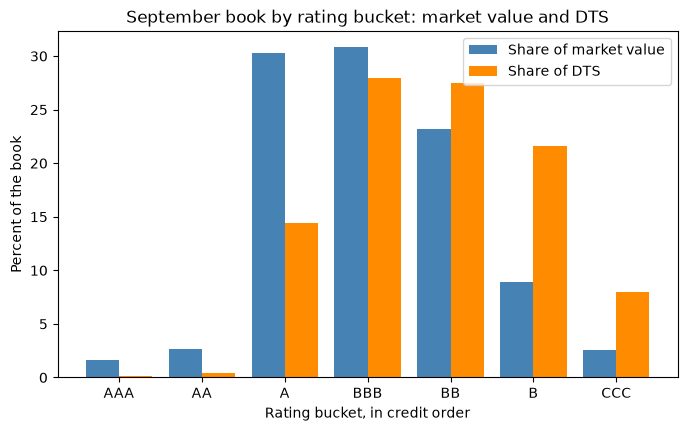

In [32]:
import matplotlib.pyplot as plt
import numpy as np

positions = np.arange(len(by_bucket))
fig, ax = plt.subplots(figsize=(8, 4.5))
# two bars per bucket, side by side
ax.bar(positions - 0.2, by_bucket["weight_pct"], width=0.4, label="Share of market value", color="steelblue")
ax.bar(positions + 0.2, by_bucket["share_of_dts_pct"], width=0.4, label="Share of DTS", color="darkorange")
ax.set_xticks(positions)
ax.set_xticklabels(by_bucket.index)
ax.set_title("September book by rating bucket: market value and DTS")
ax.set_xlabel("Rating bucket, in credit order")
ax.set_ylabel("Percent of the book")
ax.legend()
plt.show()

* From AAA to BBB, each bucket's share of market value (blue) is larger than its share of DTS (orange); from BB down, the DTS share is the larger. A description of where the spread exposure of this invented book sits, nothing more.

Q. Which ten bonds contribute the most to the book's DTS?

In [33]:
top_ten = book.nlargest(10, "dts_contribution")
print(f"the ten carry {top_ten['dts_contribution'].sum() / book_dts * 100:.1f} percent of the book's DTS "
      f"on {top_ten['weight_pct'].sum():.2f} percent of its value")
top_ten[["cusip", "ticker", "rating", "oas", "spread_duration_bm", "dts_bm", "weight_pct", "dts_contribution"]].round(3)

the ten carry 23.8 percent of the book's DTS on 7.96 percent of its value


,cusip,ticker,rating,oas,spread_duration_bm,dts_bm,weight_pct,dts_contribution
111,99066OAD2,NEVN,B-,719,6.120,4400.376,0.840,36.950
132,99038MAE9,PRAN,CCC+,871,5.058,4405.100,0.792,34.910
194,99129ZAB6,ZARL,BB+,367,6.756,2479.629,1.070,26.543
17,99009JAA9,CLDB,B,1446,4.513,6526.171,0.398,25.949
191,99036KAA3,XANL,CCC,547,5.823,3184.955,0.708,22.551
144,99046UAA9,SKEN,B+,371,5.990,2222.300,1.015,22.550
84,99004EAB3,HLVF,B+,418,10.218,4271.041,0.508,21.714
133,99145PAA0,PRAR,B-,468,4.857,2272.952,0.924,21.004
48,99098UAC2,ELVA,B,371,7.285,2702.775,0.765,20.666
9,99033HAF2,CLAE,BBB-,183,11.770,2153.933,0.935,20.138


* The ten carry 23.8 percent of the book's DTS on 7.96 percent of its value; 9 of the ten are High Yield. The largest, NEVN `99066OAD2`, contributes 36.950 from a weight of 0.84 percent and a DTS of 4400.4.
* A bond reaches this list through a wide spread, a long spread duration, a large weight, or some of each. The table lists where the DTS of the synthetic book sits on 30 September 2026. It is not a view on any of the ten.

## Excel Side by Side

Today's Excel, in one place. Every formula was tested in Excel, for Bezane Finance (`99080CAE8`) and for the whole book.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Price at the yield | `bondmath.price(s, m, 7.0, 5.606)` | `=PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,5.606/100,100,2,0)` (B1) | 106.726595 |
| Spread 1 bp lower | `bondmath.price(s, m, 7.0, 5.606 - 0.01)` | `=PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,5.606/100-0.0001,100,2,0)` (B2) | 106.776909 |
| Spread 1 bp higher | `bondmath.price(s, m, 7.0, 5.606 + 0.01)` | `=PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,5.606/100+0.0001,100,2,0)` (B3) | 106.676310 |
| Accrued | `bondmath.accrued_interest(s, m, 7.0)` | `=100*7/100/2*COUPDAYBS(DATE(2026,9,30),DATE(2032,6,18),2,0)/COUPDAYS(DATE(2026,9,30),DATE(2032,6,18),2,0)` (B4) | 1.983333 |
| Spread duration | `bondmath.spread_duration(s, m, 7.0, 5.606)` | `=(B2-B3)/(2*0.0001)/(B1+B4)` | 4.626970799 |
| Modified duration | `bondmath.modified_duration(s, m, 7.0, 5.606)` | `=MDURATION(DATE(2026,9,30),DATE(2032,6,18),7/100,5.606/100,2,0)` | 4.626970521 |
| Curve plus spread, 1 bp wider | `bondmath.price(s, m, 7.0, 4.136 + 148 / 100)` | `=PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,(4.136+(147+1)/100)/100,100,2,0)` | 106.676310 |
| DTS | `bondmath.dts(spread_duration, 147)` | `=B5*147` | 680.1647 |
| Book DTS | `(market_value * dts).sum() / market_value.sum()` | `=SUMPRODUCT(G2:G201,M2:M201)/SUM(G2:G201)` | 1064.1105 |
| DTS of one bucket | `groupby("bucket")["dts_contribution"].sum()` | `=SUMIFS(O2:O201,B2:B201,"BBB")` | 297.2402 |

The spread duration also fits in one cell, as the docstring writes it: tested, `=(PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,5.606/100-0.0001,100,2,0)-PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,5.606/100+0.0001,100,2,0))/(2*0.0001)/(PRICE(DATE(2026,9,30),DATE(2032,6,18),7/100,5.606/100,100,2,0)+100*7/100/2*COUPDAYBS(DATE(2026,9,30),DATE(2032,6,18),2,0)/COUPDAYS(DATE(2026,9,30),DATE(2032,6,18),2,0))` returns 4.626970799149981, the same as B5.

To try it: type B1 to B5 for Bezane in a blank sheet, then change the yield in all three `PRICE` cells and watch the spread duration follow. Then add `=MDURATION(...)` beside it.

## Save the Day with Git

First, commit today's work. Then today's Git step: **find the commit where a number first appeared**, with `git log -S`.

Q. What has changed since the start of the day?

In [34]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M bondmath.py
 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


 bondmath.py      | 34 ++++++++++++++++++++++++++++++++++
 test_bondmath.py | 23 +++++++++++++++++++++++
 2 files changed, 57 insertions(+)


* ` M` beside both files: 34 lines added to `bondmath.py` and 23 to `test_bondmath.py`. The `??` lines are the two reference files and `__pycache__/`; this work folder has no `.gitignore`.

Q. Commit today's work.

In [35]:
# the subject says what, the body says why; -3 shows the last three commits
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Add spread_duration and dts, reproducing the spread_duration and dts columns" -m "Spread duration and DTS feed the book's risk report on day 14."
!git -C "{work}" log --oneline -3

a17595b Add spread_duration and dts, reproducing the spread_duration and dts columns
754578d Day 12: Spread over the Curve
8ffc22c Day 11: Treasury Curve Interpolation


Today's code divides by 10000 to turn basis points into a decimal. Where else does that number appear, and when did it arrive? `git log -S "10000"` lists the commits that changed **how many times** the text `10000` appears in the files: the commits that added it or removed it. Git calls this the pickaxe.

Q. Which commits added or removed the text 10000?

In [36]:
# the pickaxe: commits that changed the number of times 10000 appears
!git -C "{work}" log -S "10000" --oneline

a17595b Add spread_duration and dts, reproducing the spread_duration and dts columns
f2bfe18 Day 9: Duration and DV01


* Two commits, newest first: today's, and **day 9**. Day 9 brought the number in with `dv01`, whose docstring gives the Excel check `=MDURATION(...)*(PRICE(...)+accrued)/10000`. The oldest commit in the list is where the number first appeared.
* `git log -S` searches the changes, not the messages: neither commit message mentions 10000.

Q. And in the test file alone?

In [37]:
# the same search, limited to one file
!git -C "{work}" log -S "10000" --oneline -- test_bondmath.py

f2bfe18 Day 9: Duration and DV01


* Only day 9: its DV01 test has a comment with the Excel formula. Today's tests do not use the number.

Q. One more: when did the name `bump_decimal` arrive?

In [38]:
# a name, searched the same way
!git -C "{work}" log -S "bump_decimal" --oneline

a17595b Add spread_duration and dts, reproducing the spread_duration and dts columns


* Only today's commit. The pickaxe finds a name as easily as a number: "when did this constant, this function, or this column name come in, and in which change?"

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. In `bondmath.py`, leave two blank lines after the last function and paste the code of the two `%%writefile -a bondmath.py` cells, in sections 13.1 and 13.3, in order, without their first lines. In `test_bondmath.py`, do the same with the two `%%writefile -a test_bondmath.py` cells, in sections 13.2 and 13.4. Save both files.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
.....................................                                    [100%]
37 passed in 0.12s
```

If you added the exercise functions of earlier days with their tests, you will see more. If a test fails, compare your file with the code in the cells.

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git add bondmath.py test_bondmath.py
git commit -m "Add spread_duration and dts, reproducing the spread_duration and dts columns" -m "Spread duration and DTS feed the book's risk report on day 14."
```

**Step 5.** Today's Git step on your own history.

```powershell
git log -S "10000" --oneline
git log -S "10000" --oneline -- test_bondmath.py
```

Your list may be longer than the notebook's: if one of your own exercise functions used 10000, its commit is listed too. The oldest commit in the list is where the number first came in.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py` and `test_bondmath.py` from the work folder under `/tmp` in the file browser. They replace yesterday's downloads.

## You Can Now

* Measure spread duration by moving the spread 1 bp each way and repricing, with `spread_duration` or three `PRICE` cells in Excel.
* Say why, for a bullet priced at the curve plus a spread, spread duration equals modified duration, why the bump sits a hair above it, and why a bond in its final coupon period differs.
* Compute DTS, spread duration times spread, and say what it measures: the price change for a move in the spread as a share of the spread.
* Reproduce the holdings file's `spread_duration` and `dts` columns from the bond math, at the course's tolerances.
* Add up the book's DTS by rating bucket and by bond, with pandas or with `SUMPRODUCT` and `SUMIFS`, as a description of the book.
* Find the commit where a number or a name first appeared, with `git log -S`.

Tomorrow, day 14, puts the book together: market value from par and the dirty price, weighted averages with a function of your own, book duration, spread, DTS, and dollar DV01, and scenarios for rates and spreads.

## Exercises

The exercises use the same twenty bonds from `benchmark.csv` as day 12: the bonds the book does not hold, every 30th, starting with the first. They are as of the same date, 30 September 2026, and were built on the same invented curve. The issuers are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It reads the data, picks the twenty bonds, and defines `check`, a small function that marks your answers.

In [39]:
from datetime import date

holdings = pd.read_csv(data_folder + "holdings.csv")
benchmark = pd.read_csv(data_folder + "benchmark.csv")
ratings = pd.read_csv(data_folder + "ratings.csv")
benchmark["as_of_date"] = pd.to_datetime(benchmark["as_of_date"]).dt.date
benchmark["maturity"] = pd.to_datetime(benchmark["maturity"]).dt.date

# every 30th benchmark bond the book does not hold, twenty in all
not_held = benchmark[~benchmark["cusip"].isin(holdings["cusip"])]
twenty = not_held.iloc[::30].head(20).reset_index(drop=True)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


twenty[["cusip", "issuer", "rating", "coupon", "maturity", "yield_pct", "oas", "spread_duration", "dts"]]

,cusip,issuer,rating,coupon,maturity,yield_pct,oas,spread_duration,dts
0,99001BAB2,Quorvane Energy,BBB,5.750,2035-08-08,5.524,122,6.834,833.7
1,99008IAD6,Osmere Chemicals,BBB-,5.250,2032-07-21,5.252,111,4.903,544.2
2,99016QAG1,Corvolvey Systems,BB+,6.000,2028-08-11,5.075,128,1.735,222.1
3,99025ZAD7,Kezazor Logistics,A,3.375,2028-03-14,4.457,71,1.399,99.3
4,99032GAB4,Queloquil Health,BBB-,6.375,2035-02-01,6.031,175,6.359,1112.8
5,99039NAF3,Bezoquil Freight,BB,4.875,2035-11-15,5.955,164,7.043,1155.1
6,99047VAF5,Quelundra Power,A,5.875,2037-11-24,5.276,89,8.041,715.6
7,99055DAB3,Mulvebran Logistics,BB,5.875,2036-02-25,6.266,194,7.060,1369.6
8,99061JAC0,Morvostrin Finance,BBB+,4.000,2038-03-05,5.425,103,8.845,911.0
9,99071TAA0,Corvoquil Metals,A-,4.625,2028-09-27,4.740,93,1.880,174.8


### Exercise 1

Q. Add a column `sd` to `twenty`: each bond's spread duration with `bondmath.spread_duration`. Check, with an `assert`, that every one is within 0.0005 + 1e-9 of the file's `spread_duration`. Store the first bond's `sd` in **ex1_first** and the largest gap to the file's column in **ex1_largest_gap**.

In [40]:
ex1_first = ...
ex1_largest_gap = ...

In [41]:
check("Exercise 1 first spread duration", ex1_first, 6.833695612710124)
check("Exercise 1 largest gap", ex1_largest_gap, 0.0004981682148255118)

Exercise 1 first spread duration: not attempted yet
Exercise 1 largest gap: not attempted yet


### Exercise 2

Q. Add a column `dts_bm` to `twenty`: `bondmath.dts` of your `sd` and the bond's `oas`. Store the largest `dts_bm` in **ex2_largest_dts** and that bond's CUSIP, a string, in **ex2_largest_cusip**. Then show the mean `dts_bm` of each rating bucket, in credit order, and describe the table in one sentence without a view on any bond or bucket.

In [42]:
ex2_largest_dts = ...
ex2_largest_cusip = ...

In [43]:
check("Exercise 2 largest DTS", ex2_largest_dts, 1369.6809973159573)
check("Exercise 2 its CUSIP", ex2_largest_cusip, '99055DAB3')

Exercise 2 largest DTS: not attempted yet
Exercise 2 its CUSIP: not attempted yet


### Exercise 3

Q. Add a function to your module. `dts_contribution(weight_pct, dts)` returns a bond's contribution to a book's DTS: its weight in percent, over 100, times its DTS. Write the docstring first: units, convention, and the Excel formula. Then add a test, `test_dts_contribution_known_case`, with a case you can check by hand. Run pytest and reload the module. Treat the twenty bonds as a small book weighted by their `market_value` column, and store the sum of their contributions, from your function, in **ex3_total**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [44]:
%%writefile -a bondmath.py


# Exercise 3: write dts_contribution(weight_pct, dts) below this line

Appending to bondmath.py


In [45]:
%%writefile -a test_bondmath.py


# Exercise 3: write test_dts_contribution_known_case() below this line

Appending to test_bondmath.py


In [46]:
# run pytest, reload the module, then add up the contributions of the twenty
ex3_total = ...

In [47]:
check("Exercise 3 DTS of the twenty", ex3_total, 760.3050140167834)

Exercise 3 DTS of the twenty: not attempted yet


### Exercise 4: AI check

You ask an AI assistant to write `spread_duration` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Spread duration in years: the percent price change for a 100 bp move in the spread.

Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
(price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
Accrued interest does not change with the spread, so clean price differences equal dirty ones.
Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [48]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_spread_duration(settlement, maturity, coupon_pct, yield_pct, frequency=2, basis="30/360", bump_bp=1.0):
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
(price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
Accrued interest does not change with the spread, so clean price differences equal dirty ones.
Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent, to move yield_pct
    bump_pct = bump_bp / 100
    price_spread_down = bondmath.price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = bondmath.price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = bondmath.dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_bp) / full_price

Q. Before you run the next cell: what should the function return for Bezane Finance, the first bond of the holdings file? Section 13.1 has the number.

In [49]:
bezane = holdings.iloc[0]
print(f"Bezane's spread duration from the assistant's function: "
      f"{assistant_spread_duration(date(2026, 9, 30), date(2032, 6, 18), bezane['coupon'], bezane['yield_pct']):.9f} years")

Bezane's spread duration from the assistant's function: 0.000462697 years


Q. Test the function against every row of Excel's reference file before you trust it.

In [50]:
# the test, written from Excel's reference rows before the code is trusted
reference = pd.read_csv("bondmath_excel_reference.csv")
basis_name = {0: "30/360", 1: "ACT/ACT"}

for row in reference.itertuples():
    # Excel's spread duration: the two bumped PRICE columns, over 2 x 0.0001, over PRICE plus accrued
    excel_spread_duration = (row.price_down_1bp - row.price_up_1bp) / (2 * 0.0001) / (row.price + row.accrued)
    result = assistant_spread_duration(date.fromisoformat(row.settlement), date.fromisoformat(row.maturity),
                                       row.coupon_pct, row.yield_pct, int(row.frequency), basis_name[row.basis])
    assert abs(result - excel_spread_duration) < 1e-6, f"{row.case_id}: {result} years against Excel's {excel_spread_duration} years"

print("Every row matches Excel's bumped PRICE formula")

AssertionError: 99080CAE8: 0.00046269707991512885 years against Excel's 4.626970799149981 years

Q. The test stops on the first row that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store the fixed function's spread duration for Bezane in **ex4_bezane**, and Bezane's DTS from it, with `bondmath.dts` and a spread of 147 bp, in **ex4_dts**.

In [51]:
# fix the function above and run the test again, then store the two answers
ex4_bezane = ...
ex4_dts = ...

In [52]:
check("Exercise 4 Bezane spread duration", ex4_bezane, 4.626970799151288)
check("Exercise 4 Bezane DTS", ex4_dts, 680.1647074752394)

Exercise 4 Bezane spread duration: not attempted yet
Exercise 4 Bezane DTS: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```